# 📝 Notebook 03 — TF-IDF & N-gram Analysis

## Topics: TF-IDF + N-grams

**Why TF-IDF?** Term Frequency-Inverse Document Frequency reveals which words are uniquely important to each category or star rating, going beyond simple word counts. A word like "refund" may appear often in Finance reviews but rarely in Pets — TF-IDF captures this.

**Why N-grams?** Single words lose context. N-grams (bigrams, trigrams) capture phrases like "customer service", "waste of money", or "highly recommend" that carry much stronger sentiment signals.

**What we observe:** Which terms define each category and rating level, and how phrases differ between positive and negative reviews.

---


## 1. Setup


In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.feature_engineering import build_tfidf_matrix, get_top_tfidf_terms, extract_ngrams, extract_ngrams_by_group
from src.visualization import *
from src.utils import print_section

set_dark_theme()
df = pd.read_csv('../data/processed/cleaned_reviews.csv')
print(f'Loaded {len(df):,} reviews')


Loaded 123,164 reviews


## 2. TF-IDF Analysis

### 2.1 Build TF-IDF Matrix


In [2]:
# Build TF-IDF matrix
tfidf_matrix, tfidf_vec = build_tfidf_matrix(df['cleaned_review'], max_features=5000)
print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'Vocabulary size: {len(tfidf_vec.get_feature_names_out())}')
print(f'Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.2f}%')


TF-IDF matrix shape: (123164, 5000)
Vocabulary size: 5000
Sparsity: 99.14%


### 2.2 Top TF-IDF Terms per Star Rating

Which words are most characteristic of each star level?


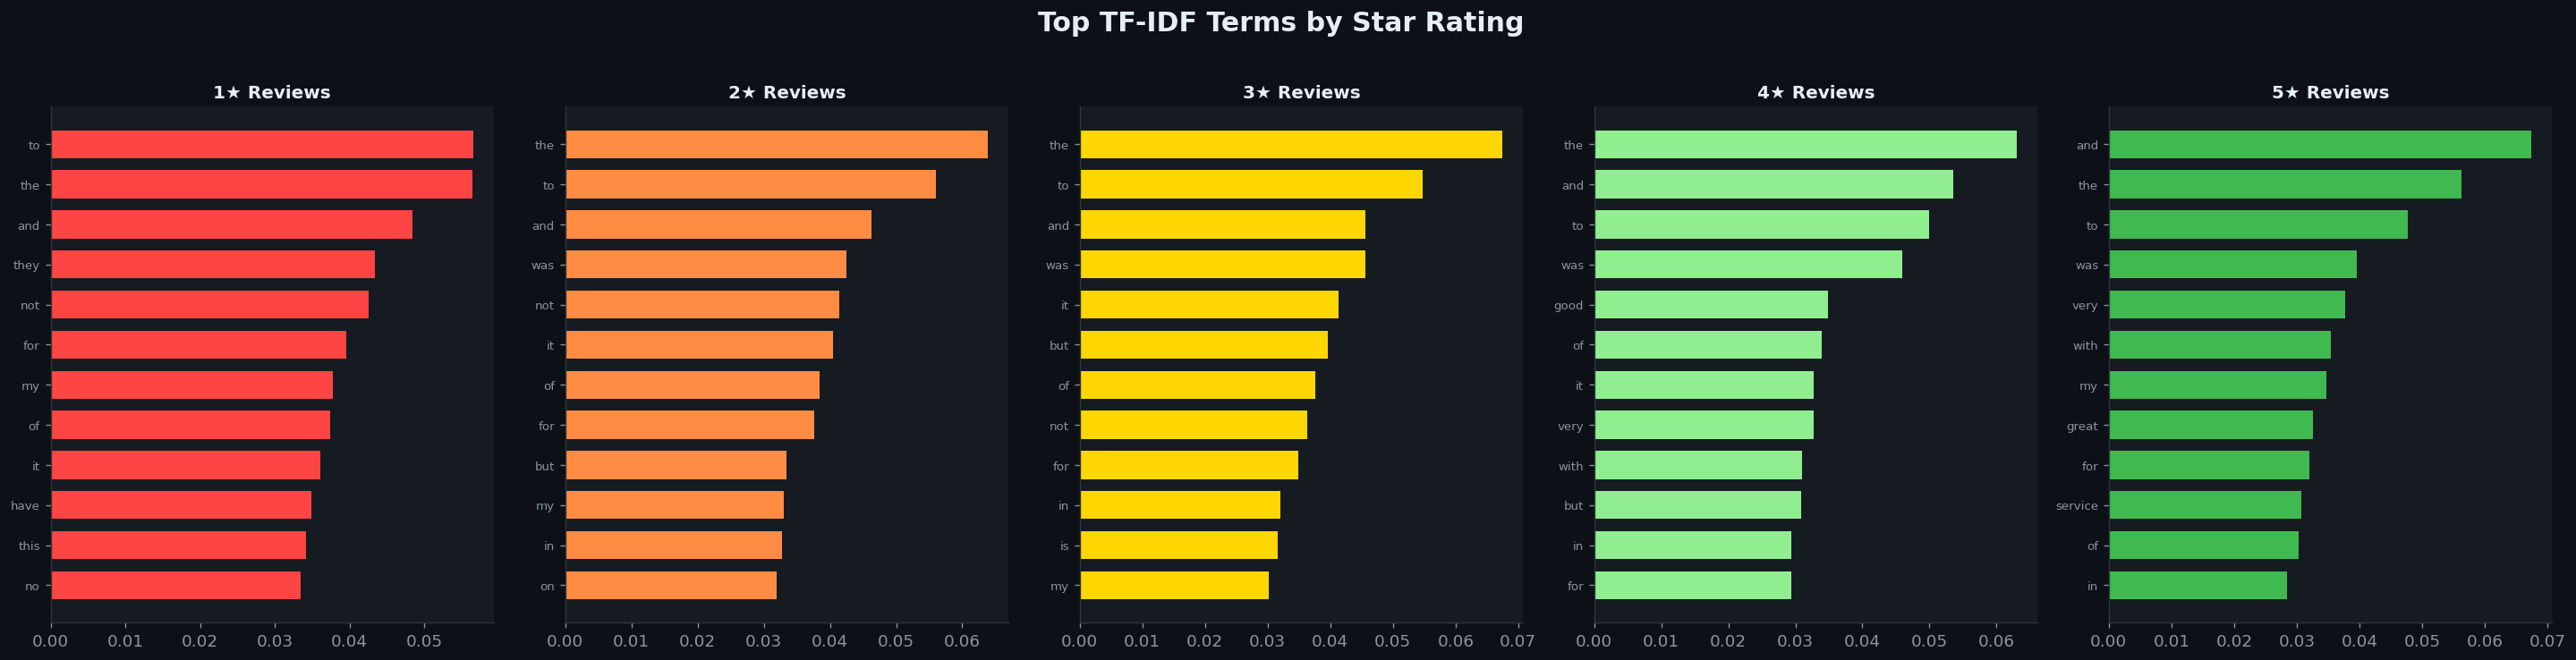

In [3]:
# Top terms per star rating
top_by_star = get_top_tfidf_terms(tfidf_matrix, tfidf_vec, df['stars'], top_n=12)

fig, axes = create_figure(1, 5, figsize=(24, 6), title='Top TF-IDF Terms by Star Rating')
for i, star in enumerate(range(1, 6)):
    star_data = top_by_star[top_by_star['group'] == star].sort_values('tfidf_score')
    axes[i].barh(range(len(star_data)), star_data['tfidf_score'], color=STAR_COLORS[star], height=0.7)
    axes[i].set_yticks(range(len(star_data)))
    axes[i].set_yticklabels(star_data['term'], fontsize=8)
    axes[i].set_title(f'{star}★ Reviews', fontsize=12, fontweight='bold')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


### 2.3 Top TF-IDF Terms per Category (Selected)

Comparing distinctive vocabulary across industries.


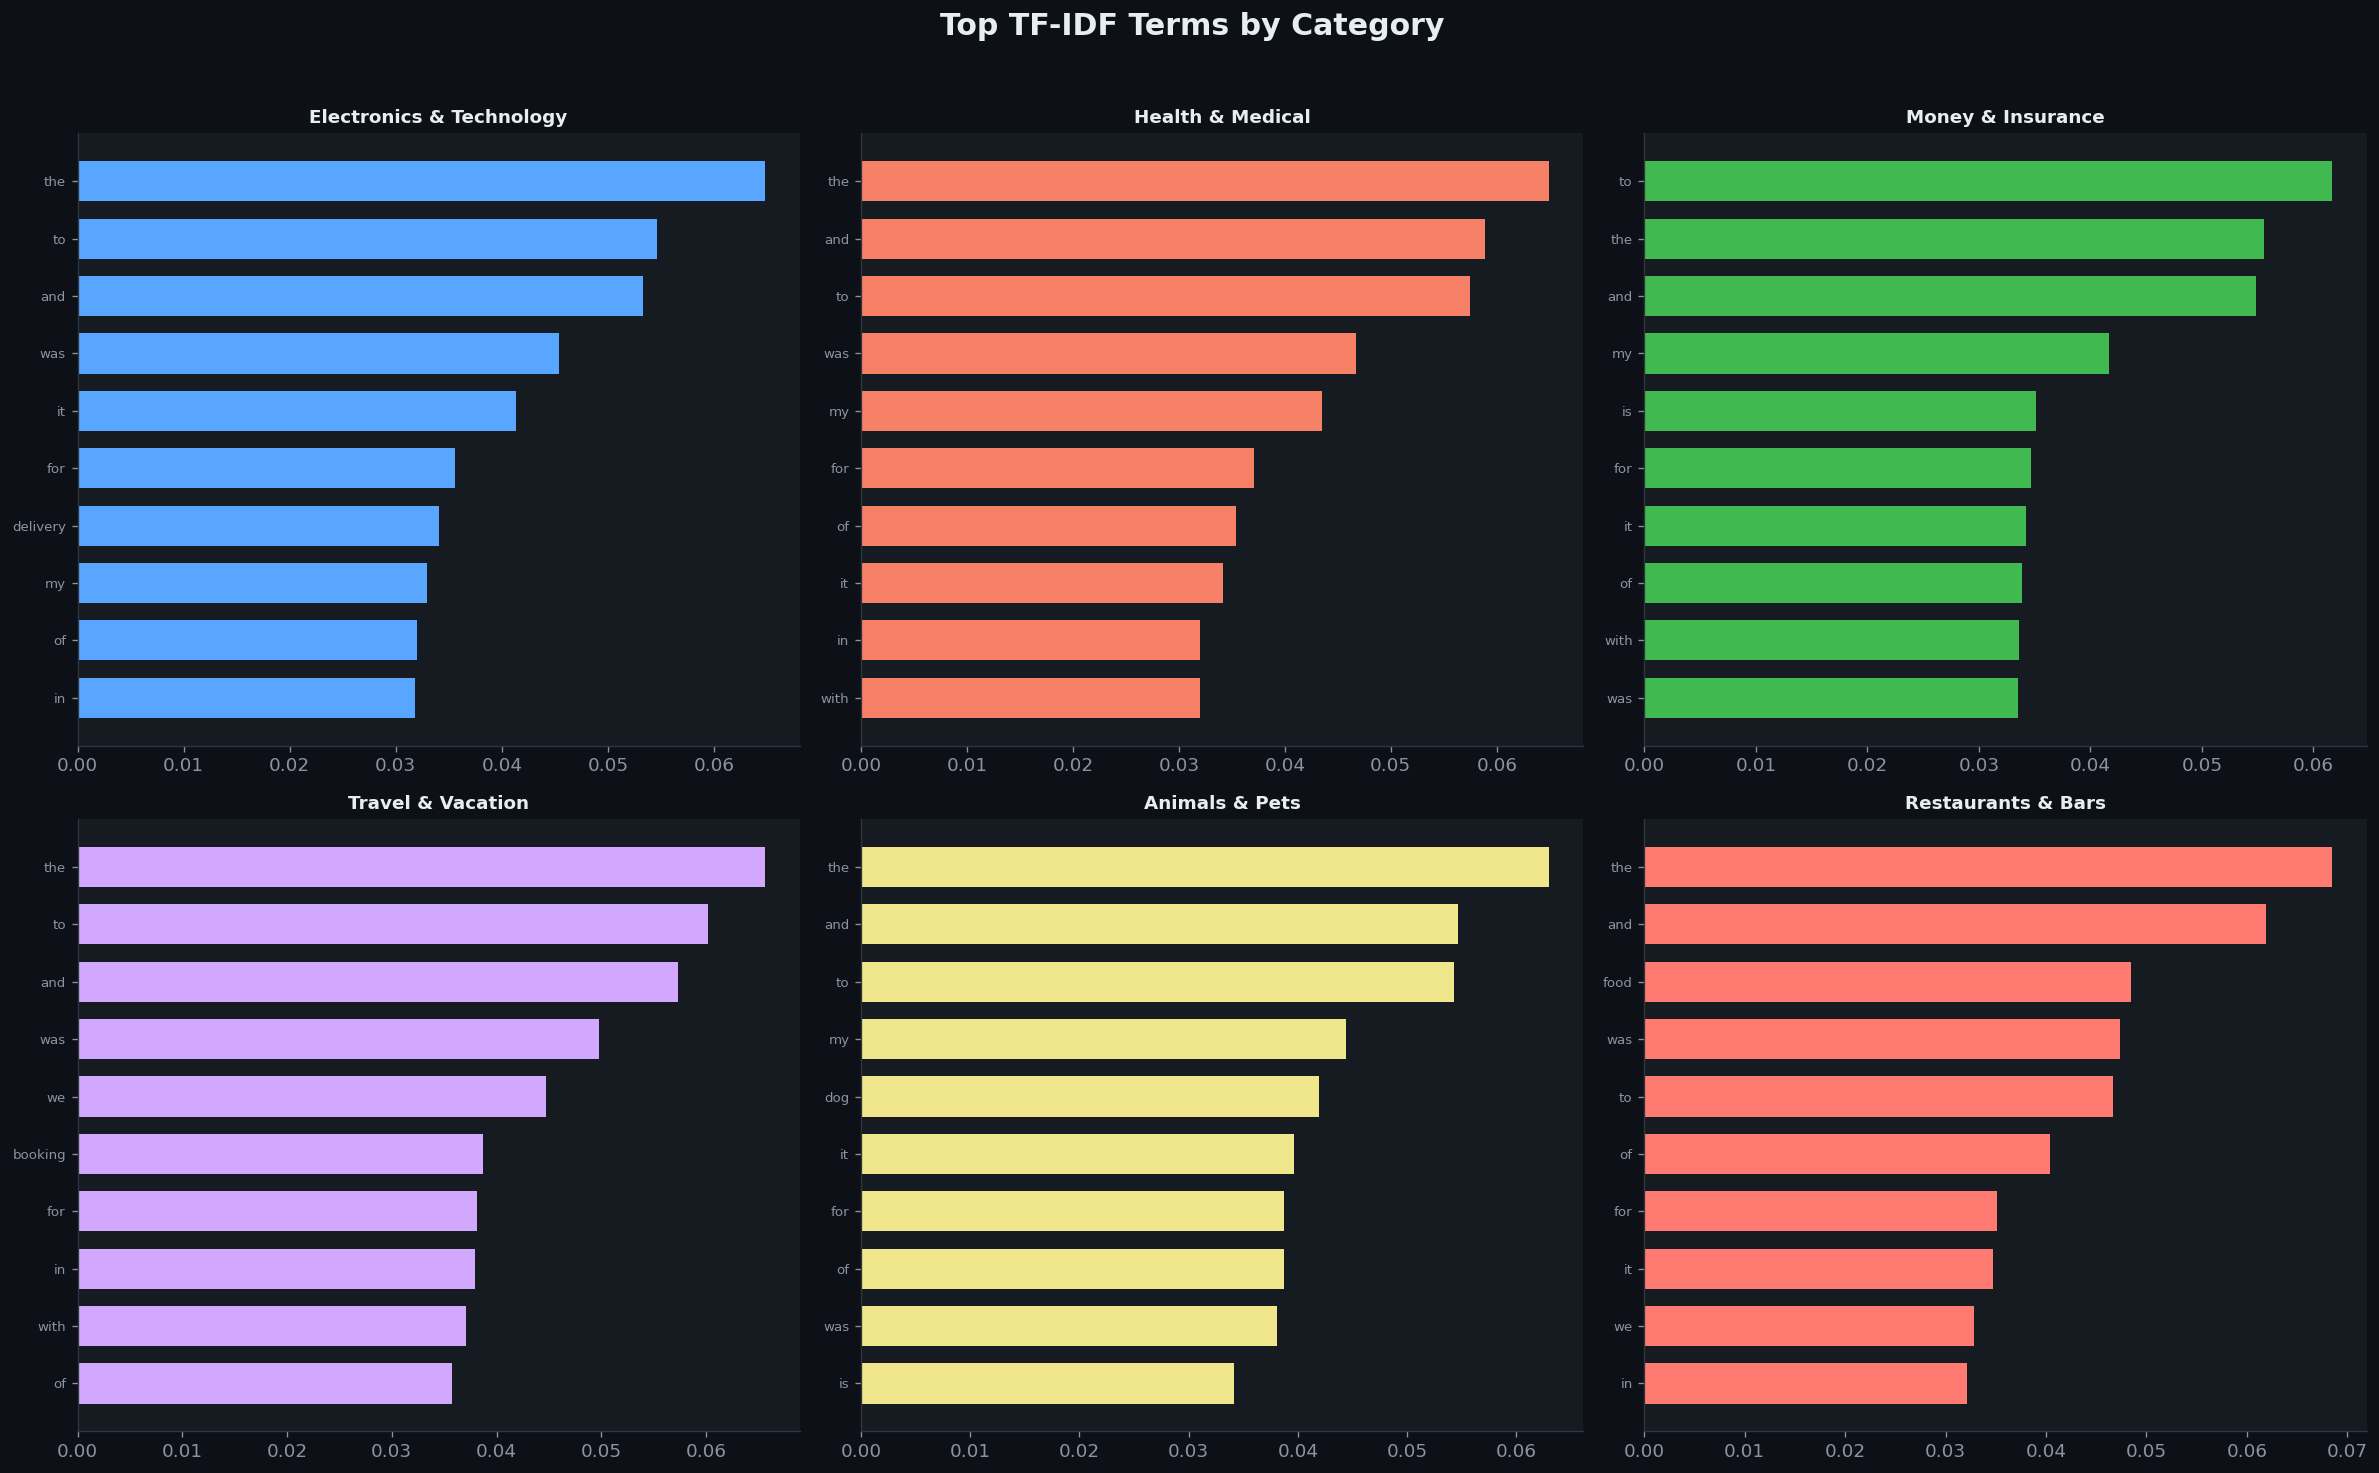

In [4]:
# Select 6 interesting categories
selected_cats = ['Electronics & Technology', 'Health & Medical', 'Money & Insurance',
                 'Travel & Vacation', 'Animals & Pets', 'Restaurants & Bars']
mask = df['category'].isin(selected_cats)
tfidf_cat, vec_cat = build_tfidf_matrix(df.loc[mask, 'cleaned_review'], max_features=3000)
top_by_cat = get_top_tfidf_terms(tfidf_cat, vec_cat, df.loc[mask, 'category'], top_n=10)

fig, axes = create_figure(2, 3, figsize=(20, 12), title='Top TF-IDF Terms by Category')
for i, cat in enumerate(selected_cats):
    ax = axes[i // 3, i % 3]
    cat_data = top_by_cat[top_by_cat['group'] == cat].sort_values('tfidf_score')
    ax.barh(range(len(cat_data)), cat_data['tfidf_score'], color=PALETTE[i], height=0.7)
    ax.set_yticks(range(len(cat_data)))
    ax.set_yticklabels(cat_data['term'], fontsize=8)
    ax.set_title(cat, fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## 3. N-gram Analysis

### 3.1 Top Bigrams Overall


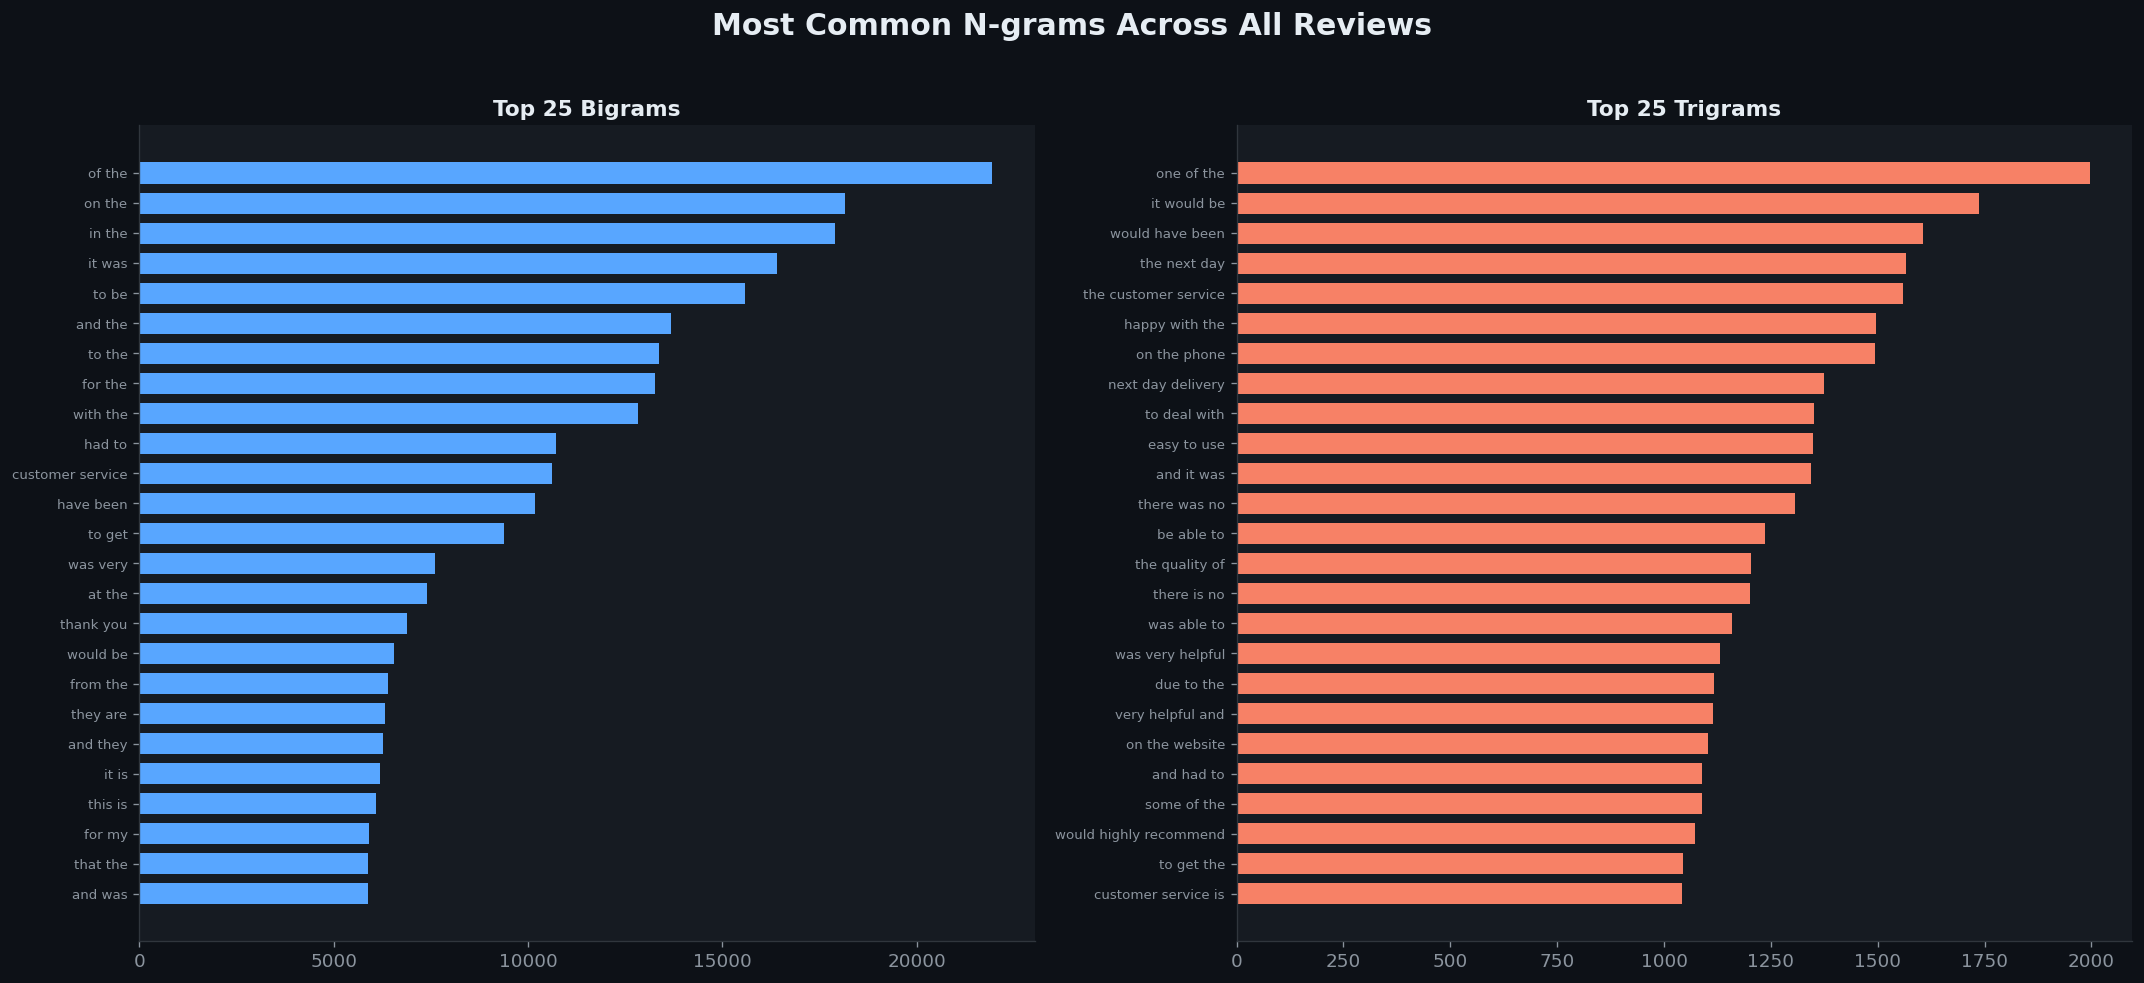

In [5]:
# Overall top bigrams and trigrams
bigrams = extract_ngrams(df['cleaned_review'], n=2, top_k=25, min_freq=10)
trigrams = extract_ngrams(df['cleaned_review'], n=3, top_k=25, min_freq=10)

fig, axes = create_figure(1, 2, figsize=(18, 8), title='Most Common N-grams Across All Reviews')

# Bigrams
bg = bigrams.sort_values('frequency')
axes[0].barh(range(len(bg)), bg['frequency'], color=PALETTE[0], height=0.7)
axes[0].set_yticks(range(len(bg)))
axes[0].set_yticklabels(bg['ngram'], fontsize=8)
axes[0].set_title('Top 25 Bigrams', fontsize=13, fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Trigrams
tg = trigrams.sort_values('frequency')
axes[1].barh(range(len(tg)), tg['frequency'], color=PALETTE[1], height=0.7)
axes[1].set_yticks(range(len(tg)))
axes[1].set_yticklabels(tg['ngram'], fontsize=8)
axes[1].set_title('Top 25 Trigrams', fontsize=13, fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### 3.2 Bigrams by Star Rating

How do the most common phrases differ between 1★ and 5★?


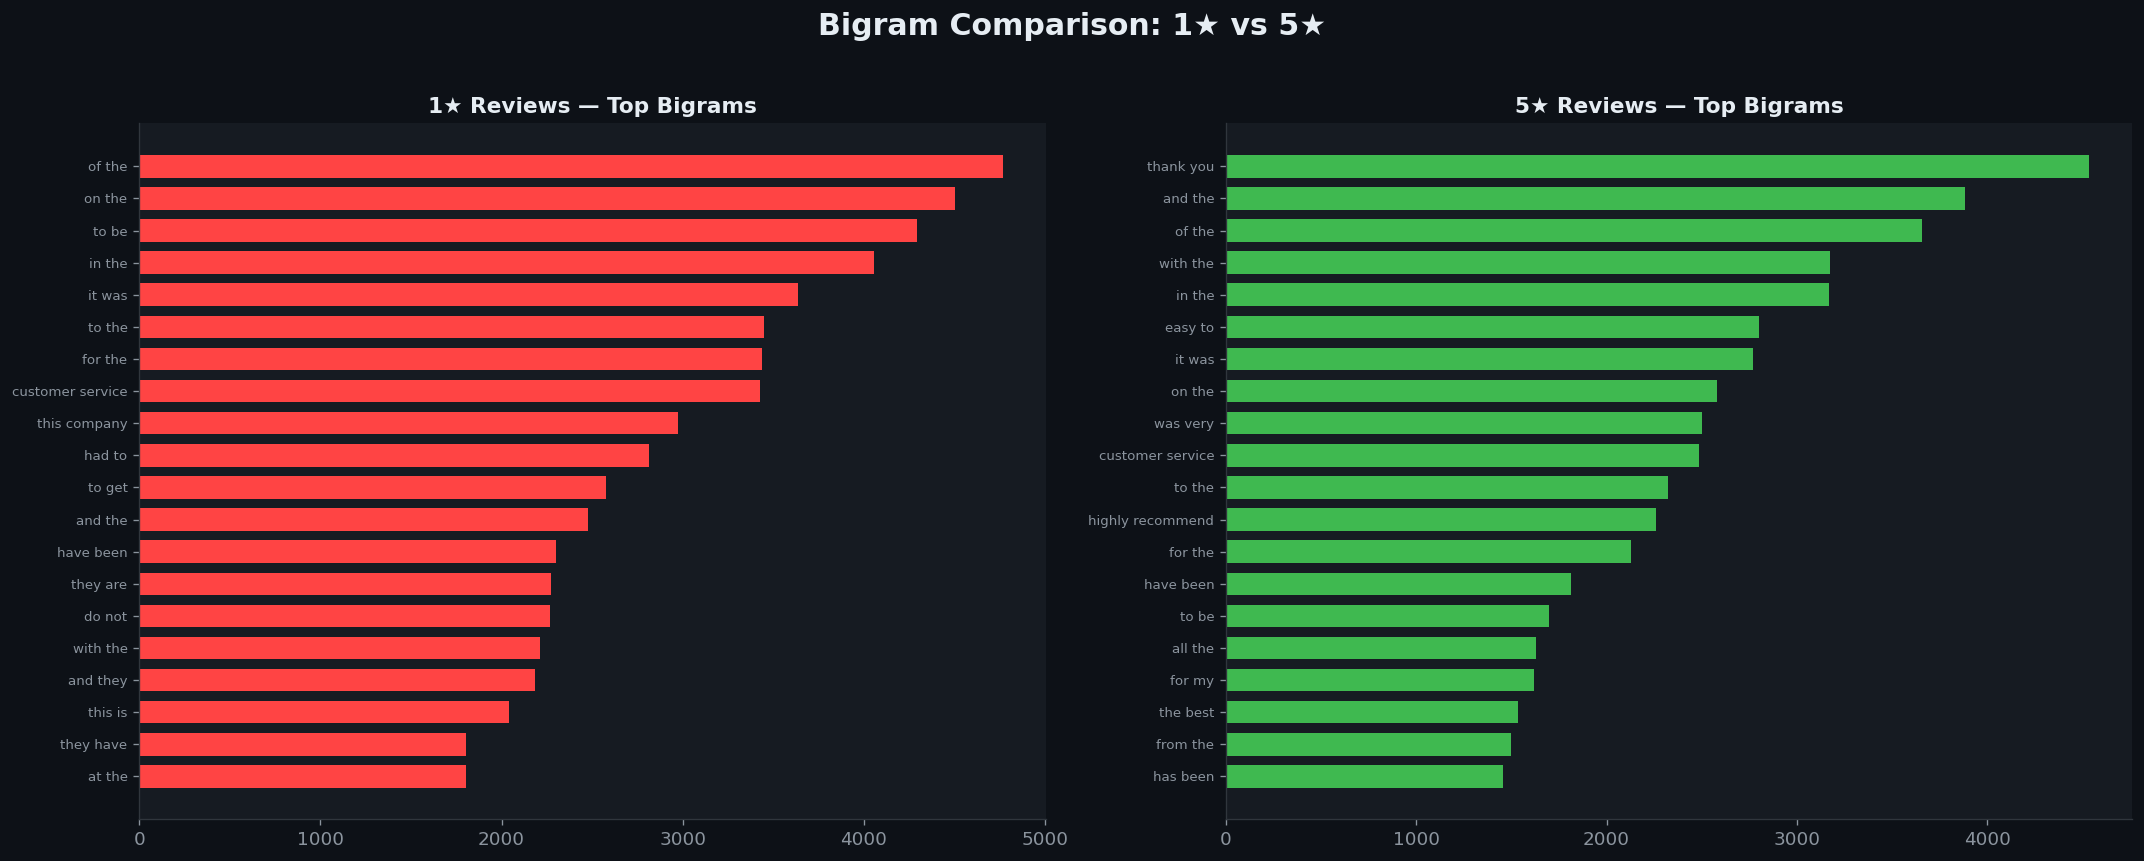

In [6]:
fig, axes = create_figure(1, 2, figsize=(18, 7), title='Bigram Comparison: 1★ vs 5★')

for i, (star, color) in enumerate([(1, '#ff4444'), (5, '#3fb950')]):
    star_texts = df[df['stars'] == star]['cleaned_review']
    bg = extract_ngrams(star_texts, n=2, top_k=20, min_freq=5).sort_values('frequency')
    axes[i].barh(range(len(bg)), bg['frequency'], color=color, height=0.7)
    axes[i].set_yticks(range(len(bg)))
    axes[i].set_yticklabels(bg['ngram'], fontsize=8)
    axes[i].set_title(f'{star}★ Reviews — Top Bigrams', fontsize=13, fontweight='bold')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## 4. 📋 Observations & Documentation

### TF-IDF Findings:
1. **Star-specific vocabulary is clear** — 1★ reviews are dominated by terms like "refund", "terrible", "worst", while 5★ reviews feature "excellent", "amazing", "recommend"
2. **Category-specific terms emerge** — TF-IDF successfully identifies domain-specific vocabulary (e.g., "pet", "dog" for Animals; "flight", "hotel" for Travel)
3. **High sparsity** — The TF-IDF matrix is ~99%+ sparse, which is normal for text data

### N-gram Findings:
1. **"Customer service"** is the dominant bigram across all ratings — it's the central topic of most Trustpilot reviews
2. **Negative bigrams** include "waste money", "never again", "stay away"
3. **Positive bigrams** include "highly recommend", "great service", "well done"
4. **Trigrams reveal complaints** — phrases like "waste of money" and "never use again" appear prominently in 1★ reviews

### Why This Matters for Later:
- TF-IDF features will be the primary input for our supervised ML models (Notebooks 09-10)
- N-gram patterns validate that text-based features carry strong discriminative power
- Category-specific vocabulary confirms that topic modeling (Notebook 07) will find meaningful clusters

---
*Next: Notebook 04 — POS Tags, NER & Language Models*
